## **Notebook PC#13**
## A reduced-size transformer designed from scratch and operating as a very simple chatbot.

**Professor:** Fernando J. Von Zuben <br>
**Cursos:** IA353A / EG453A (FEEC/Unicamp) - 1s2026 <br>
**Aluno(a):** ______ **RA:** <br>
**Aluno(a):** ______ **RA:** <br>


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import (
    TextVectorization,
    Embedding,
    Dense,
    LayerNormalization,
    Dropout,
    MultiHeadAttention
)
from tensorflow.keras.models import Model

# =========================================================
# 1. SMALL CHATBOT DATASET
# =========================================================

# Simple educational conversational corpus
# Inspired by toy chatbot examples from literature/tutorials

pairs = [
    ("hello", "hi"),
    ("how are you", "i am fine"),
    ("what is your name", "my name is mini transformer"),
    ("where do you live", "i live inside a computer"),
    ("what do you do", "i answer questions"),
    ("good morning", "good morning"),
    ("good night", "sleep well"),
    ("thank you", "you are welcome"),
    ("bye", "goodbye"),
    ("who created you", "students created me"),
    ("what is machine learning", "machine learning allows computers to learn"),
    ("what is deep learning", "deep learning uses neural networks"),
    ("what is attention", "attention helps the model focus"),
    ("what is a transformer", "a transformer uses attention mechanisms"),
    ("can you help me", "yes i can help you"),
    ("what is tensorflow", "tensorflow is a machine learning library"),
    ("what is keras", "keras is a deep learning api"),
    ("tell me a joke", "i am still learning humor"),
    ("are you intelligent", "i try to learn from data"),
    ("what is artificial intelligence", "artificial intelligence simulates intelligent behavior")
]

# =========================================================
# 2. SPECIAL TOKENS
# =========================================================

START_TOKEN = "start"
END_TOKEN = "end"

questions = [q for q, a in pairs]
answers = [f"{START_TOKEN} {a} {END_TOKEN}" for q, a in pairs]

# =========================================================
# 3. TEXT VECTORIZATION
# =========================================================

VOCAB_SIZE = 1000
SEQ_LENGTH = 20

vectorizer = TextVectorization(
    max_tokens=VOCAB_SIZE,
    output_mode="int",
    output_sequence_length=SEQ_LENGTH
)

all_text = questions + answers
vectorizer.adapt(all_text)

vocab = vectorizer.get_vocabulary()
word_to_index = dict(zip(vocab, range(len(vocab))))
index_to_word = dict(enumerate(vocab))

# =========================================================
# 4. TOKENIZATION
# =========================================================

encoder_inputs = vectorizer(np.array([[q] for q in questions])).numpy()
decoder_full = vectorizer(np.array([[a] for a in answers])).numpy()

# Teacher forcing:
# decoder_input  -> receives previous correct token
# decoder_target -> expected next token

decoder_inputs = decoder_full[:, :-1]
decoder_targets = decoder_full[:, 1:]

# =========================================================
# 5. POSITIONAL EMBEDDING
# =========================================================

class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, vocab_size, embed_dim, max_len):
        super().__init__()

        self.token_embeddings = Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim
        )

        self.position_embeddings = Embedding(
            input_dim=max_len,
            output_dim=embed_dim
        )

        self.max_len = max_len

    def call(self, x):

        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)

        embedded_tokens = self.token_embeddings(x)
        embedded_positions = self.position_embeddings(positions)

        return embedded_tokens + embedded_positions


# =========================================================
# 6. TRANSFORMER ENCODER
# =========================================================

class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads):
        super().__init__()

        self.attention = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.dense_proj = tf.keras.Sequential([
            Dense(dense_dim, activation="relu"),
            Dense(embed_dim)
        ])

        self.layernorm_1 = LayerNormalization()
        self.layernorm_2 = LayerNormalization()

    def call(self, inputs):

        attention_output = self.attention(
            query=inputs,
            value=inputs,
            key=inputs
        )

        proj_input = self.layernorm_1(inputs + attention_output)

        proj_output = self.dense_proj(proj_input)

        return self.layernorm_2(proj_input + proj_output)


# =========================================================
# 7. TRANSFORMER DECODER
# =========================================================

class TransformerDecoder(tf.keras.layers.Layer):
    def __init__(self, embed_dim, dense_dim, num_heads):
        super().__init__()

        self.attention_1 = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.attention_2 = MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        self.dense_proj = tf.keras.Sequential([
            Dense(dense_dim, activation="relu"),
            Dense(embed_dim)
        ])

        self.layernorm_1 = LayerNormalization()
        self.layernorm_2 = LayerNormalization()
        self.layernorm_3 = LayerNormalization()

    def causal_attention_mask(self, batch_size, n_dest, n_src):

        i = tf.range(n_dest)[:, None]
        j = tf.range(n_src)

        mask = tf.cast(i >= j, dtype="int32")
        mask = tf.reshape(mask, (1, n_dest, n_src))

        mult = tf.concat(
            [[batch_size], tf.constant([1, 1], dtype=tf.int32)],
            axis=0
        )

        return tf.tile(mask, mult)

    def call(self, inputs, encoder_outputs):

        batch_size = tf.shape(inputs)[0]
        seq_len = tf.shape(inputs)[1]

        causal_mask = self.causal_attention_mask(
            batch_size,
            seq_len,
            seq_len
        )

        attention_output_1 = self.attention_1(
            query=inputs,
            value=inputs,
            key=inputs,
            attention_mask=causal_mask
        )

        out_1 = self.layernorm_1(inputs + attention_output_1)

        attention_output_2 = self.attention_2(
            query=out_1,
            value=encoder_outputs,
            key=encoder_outputs
        )

        out_2 = self.layernorm_2(out_1 + attention_output_2)

        proj_output = self.dense_proj(out_2)

        return self.layernorm_3(out_2 + proj_output)


# =========================================================
# 8. MODEL PARAMETERS
# =========================================================

EMBED_DIM = 64
DENSE_DIM = 128
NUM_HEADS = 4

# =========================================================
# 9. BUILD TRANSFORMER
# =========================================================

# Encoder
encoder_inputs_layer = tf.keras.Input(shape=(SEQ_LENGTH,), dtype="int64")

x = PositionalEmbedding(VOCAB_SIZE, EMBED_DIM, SEQ_LENGTH)(
    encoder_inputs_layer
)

encoder_outputs = TransformerEncoder(
    EMBED_DIM,
    DENSE_DIM,
    NUM_HEADS
)(x)

# Decoder
decoder_inputs_layer = tf.keras.Input(shape=(SEQ_LENGTH - 1,), dtype="int64")

x = PositionalEmbedding(
    VOCAB_SIZE,
    EMBED_DIM,
    SEQ_LENGTH
)(decoder_inputs_layer)

x = TransformerDecoder(
    EMBED_DIM,
    DENSE_DIM,
    NUM_HEADS
)(x, encoder_outputs)

x = Dropout(0.3)(x)

decoder_outputs = Dense(VOCAB_SIZE, activation="softmax")(x)

# Complete model
transformer = Model(
    [encoder_inputs_layer, decoder_inputs_layer],
    decoder_outputs
)

# =========================================================
# 10. COMPILE MODEL
# =========================================================

transformer.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

transformer.summary()

# =========================================================
# 11. TRAINING (TEACHER FORCING)
# =========================================================

print("\nTraining started...\n")

history = transformer.fit(
    [encoder_inputs, decoder_inputs],
    decoder_targets,
    batch_size=4,
    epochs=300,
    verbose=1
)

print("\nTraining finished.\n")

In [ ]:
# =========================================================
# 12. CHATBOT INFERENCE
# =========================================================

start_token_id = word_to_index[START_TOKEN]
end_token_id = word_to_index[END_TOKEN]

def decode_sequence(input_sentence):

    # Encode user sentence
    encoder_input = vectorizer(
        np.array([[input_sentence]])
    )

    # Decoder starts with START token
    decoded_sentence = [start_token_id]

    for i in range(SEQ_LENGTH - 1):

        decoder_input = np.array([decoded_sentence])

        # Pad sequence
        decoder_input = tf.keras.preprocessing.sequence.pad_sequences(
            decoder_input,
            maxlen=SEQ_LENGTH - 1,
            padding="post"
        )

        # Predict next token
        predictions = transformer.predict(
            [encoder_input, decoder_input],
            verbose=0
        )

        predicted_token_id = np.argmax(
            predictions[0, i, :]
        )

        # Stop if END token
        if predicted_token_id == end_token_id:
            break

        decoded_sentence.append(predicted_token_id)

    # Convert ids to words
    predicted_words = [
        index_to_word.get(token_id, "")
        for token_id in decoded_sentence[1:]
    ]

    return " ".join(predicted_words)


# =========================================================
# 13. TEST THE CHATBOT
# =========================================================

test_sentences = [
    "hello",
    "what is attention",
    "what is machine learning",
    "are you intelligent",
    "who created you",
    "what if I ask you a question that has nothing to do with those used in your training",
    "are you happy",
    "bye"
]

print("\n================ CHATBOT TEST ================\n")

for sentence in test_sentences:

    response = decode_sequence(sentence)

    print(f"User     : {sentence}")
    print(f"Chatbot  : {response}")
    print()

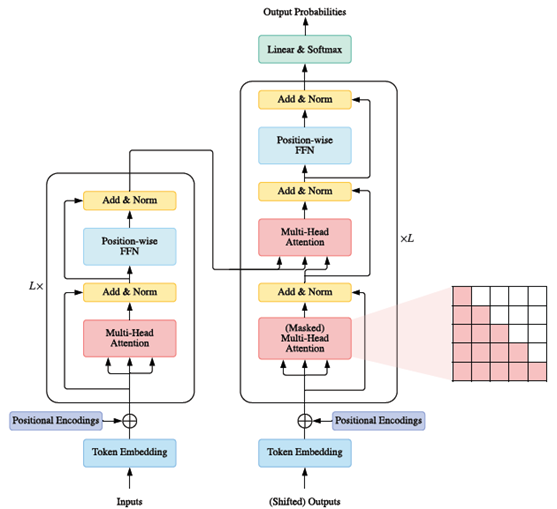

<font color="green">
Atividade (a) <br>
Qual é a função da camada de embedding em um transformer e por que ela é necessária antes do mecanismo de atenção?

Resposta:

<font color="green">
Atividade (b) <br>
Por que a codificação posicional é necessária e como ela permite distinguir "o gato mordeu o cão" de "o cão mordeu o gato"?

Resposta:

<font color="green">
Atividade (c) <br>
Qual é a motivação para utilizar múltiplas cabeças de atenção?

Resposta:

<font color="green">
Atividade (d) <br>
Como o modelo gera frases palavra por palavra? É correto afirmar que transformers criam textos longos e coerentes, pois a cada novo passo, ele "olha" para tudo o que já escreveu anteriormente?

Resposta: